<a href="https://colab.research.google.com/github/rahminurulainunfitrah/Praktikum-Analisis-Deret-Waktu/blob/main/TUGAS_KELOMPOK_MINGGU_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1><center> EKSPLORASI DERET WAKTU  </center></h1><center> Kelompok 8:

1. Rahmi Nurul Ainun Fitrah
2. Francisca Juventini Mandas
3. Fitri Diana Musa </center>

<center>
_____________________________________________________________________________________________________________________________
</center>


In [ ]:
#Install terlebih dahulu package PythonTsa
!pip install PythonTsa

# menginstall package pydataset
!pip install pydataset

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 441.1/441.1 kB 16.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 48.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pydataset: filename=pydataset-0.2.0-py3-none-any.whl size=15939458 sha256=6037ed8ebd6df0746add1e18792d55a9445c68760680196d0aba0bd2d80fb8cb
  Stored in directory: /root/.cache/pip/wheels/49/2a/45/180e1199b8d925b5c43df8f9850dcc2e5dfc94e3e99a55b83e
Successfully built pydataset


# Import Library

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from PythonTsa.plot_acf_pacf import acf_pacf_fig
from pydataset import data
from statsmodels.datasets import get_rdataset

import warnings
warnings.filterwarnings("ignore")

initiated datasets repo at: /root/.pydataset/


# Data Harga Telur di Semarang

In [ ]:
url = "https://raw.githubusercontent.com/lailynissa/StatistikaSainsData/d46f1a04dbc67ea745c903f48e7b879ca5b83ff4/harga%20telur%20semarang.xlsx"

telur = pd.read_excel(url)

In [ ]:
#melihat struktur data
telur.dtypes

,0
periode,datetime64[ns]
semarang,float64


In [ ]:
# melihat 5 data pertama
telur.head()

,periode,semarang
0,2023-01-02,27900.0
1,2023-01-03,27900.0
2,2023-01-04,28000.0
3,2023-01-05,28000.0
4,2023-01-06,28000.0


In [ ]:
#melihat 5 data terakhir
telur.tail()

,periode,semarang
359,2023-12-27,26800.00000
360,2023-12-28,26700.00000
361,2023-12-29,26700.00000
362,2023-12-30,23572.07194
363,2023-12-31,23572.07194


In [ ]:
#cek missing values
telur.isnull().sum()

,0
periode,0
semarang,0


# Plot Deret Waktu Harga Telur

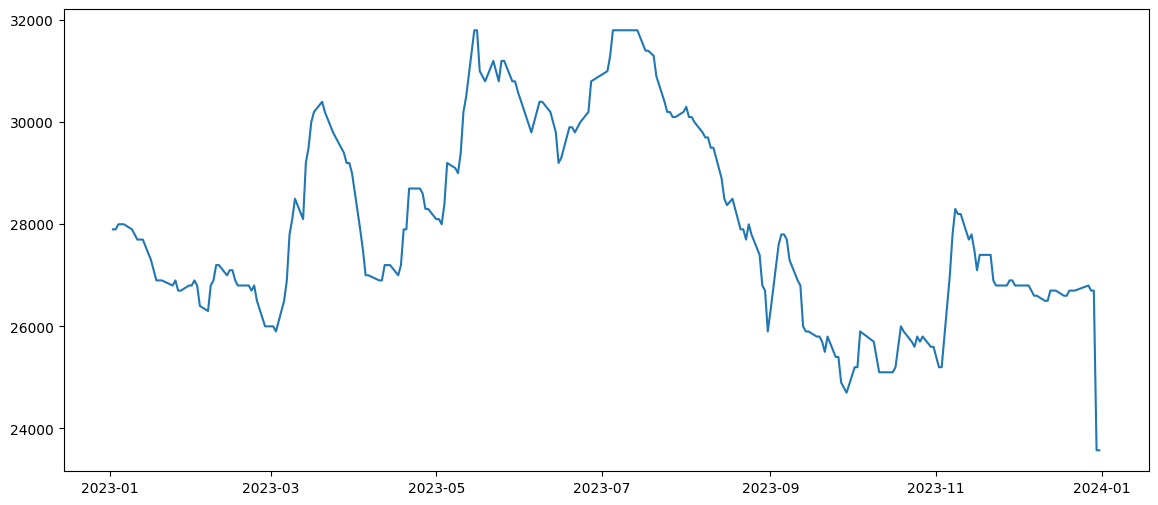

In [ ]:
plt.figure(figsize=(14,6))
plt.plot(telur['periode'],telur['semarang']); plt.show()

**Interpretasi:** Plot deret waktu menunjukkan bahwa harga telur di Semarang mengalami fluktuasi sepanjang tahun 2023. Pergerakan harga tidak menunjukkan pola tren yang konsisten karena terdapat beberapa periode kenaikan dan penurunan. Pada awal tahun harga cenderung menurun, kemudian mengalami peningkatan hingga pertengahan tahun. Setelah itu, harga kembali menurun dan mengalami kenaikan pada sekitar November sebelum bergerak relatif stabil hingga akhir periode. Dengan demikian, deret waktu menunjukkan adanya dinamika dan variasi harga yang cukup besar selama periode pengamatan.

# Plot ACF dan PACF

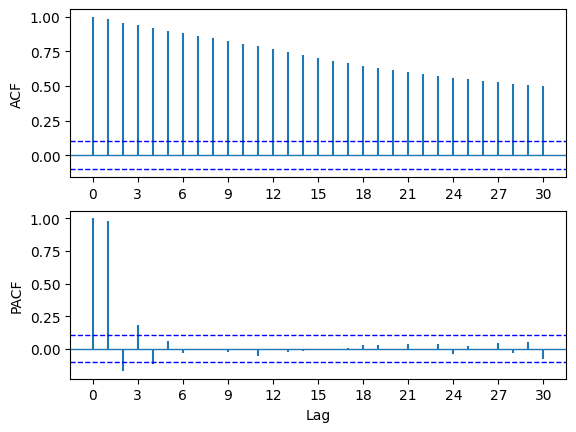

In [ ]:
# membuat plot ACF dan PACF contoh dari data harga telur
acf_pacf_fig(telur['semarang'], both=True, lag=30)

**Interpretasi:**
Berdasarkan plot ACF, terlihat bahwa nilai autokorelasi pada lag awal cukup tinggi dan kemudian menurun secara perlahan seiring bertambahnya lag. Pola ini menunjukkan bahwa ACF mengalami tails off, karena nilai autokorelasi tidak langsung berhenti pada lag tertentu, tetapi berangsur-angsur mendekati nol.

Pada plot PACF, terlihat bahwa pengaruh paling kuat terdapat pada lag 1, sedangkan setelah lag tersebut nilai PACF cenderung berada di sekitar nol. Pola ini menunjukkan cut-off setelah lag 1.

Berdasarkan plot ACF dan PACF tersebut, terdapat indikasi adanya komponen autoregressive pada lag 1. Tetapi, kestasioneran data tetap perlu diperiksa sebelum menentukan model ARIMA yang digunakan.

Selain berdasarkan plot deret, kestasioneran suatu deret dapat diperiksa menggunakan uji statistik, salah satunya adalah uji ADF. Hipotesis yang digunakan dalam uji ADF adalah

$H_0$ menyatakan deret tidak stasioner

$H_1$ menyatakan deret stasioner.

Kriteria keputusan: Tolak $H_0$ jika p-value < 0.05

# Uji ADF

In [ ]:
# uji unit-root Augmented Dickey Fuller
from statsmodels.tsa.stattools import adfuller

adfuller(telur['semarang'])[1]

0.569633409766498

**Interpretasi:** Berdasarkan hasil uji Augmented Dickey-Fuller (ADF), diperoleh nilai $p$-value sebesar $0{.}5696$. Dengan menggunakan taraf signifikansi $\alpha = 0{.}05$, diperoleh

*p-value* = 0.5696 > 0.05

Maka, gagal tolak $H_0$. Dengan demikian, data harga telur di Semarang belum stasioner pada tingkat level. Oleh karena itu, diperlukan proses *differencing* memperoleh data yang stasioner sebelum dilakukan pemodelan ARIMA.

# Dekomposisi

In [ ]:
pd.infer_freq(telur['periode'])

'D'

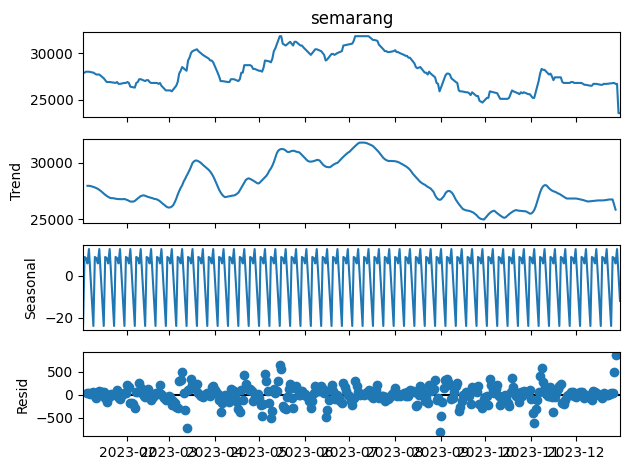

In [ ]:
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

telur2 = telur.set_index('periode')

result = seasonal_decompose(
    telur2['semarang'],
    model='additive',
    period=7
)

result.plot()

plt.show()

**Interpretasi:** Berdasarkan hasil dekomposisi, deret waktu harga telur di Semarang terdiri atas pola trend, seasonal, dan residual. Komponen trend menunjukkan adanya perubahan level harga sepanjang periode pengamatan, sedangkan komponen seasonal menunjukkan pola yang berulang secara teratur. Komponen residual berfluktuasi di sekitar nilai nol dengan beberapa penyimpangan pada periode tertentu. Dengan demikian, deret waktu harga telur menunjukkan adanya pola trend dan musiman yang perlu diperhatikan dalam pemodelan deret waktu selanjutnya.

# Cek Stasioneritas dalam Ragam

In [ ]:
telur['semarang'].min()

23572.07194

**Interpretasi:** Berdasarkan pemeriksaan nilai minimum, harga telur di Semarang memiliki nilai minimum sebesar 23572,072. Nilai tersebut lebih besar dari nol, sehingga data memenuhi persyaratan untuk dilakukan transformasi Box-Cox tanpa memerlukan penambahan konstanta. Selanjutnya, transformasi Box-Cox dilakukan untuk menstabilkan ragam deret waktu sebelum proses differencing untuk mencapai stasioneritas dalam nilai tengah.

In [ ]:
# Mencari lambda Box-Cox
from scipy.stats import boxcox, boxcox_llf

data_boxcox, lambda_fit, ci = boxcox(
    telur['semarang'],
    alpha=0.05
)

print('Nilai lambda:', lambda_fit)
print('Interval kepercayaan lambda:', ci)

Nilai lambda: -1.898726467612791
Interval kepercayaan lambda: (-3.4270430959099283, -0.35213718285668094)


**Interpretasi:** Berdasarkan hasil estimasi transformasi Box-Cox, diperoleh nilai parameter $\lambda$ sebesar $-1,8987$ dengan interval kepercayaan $95%$ sebesar $(-3,4270;-0,3521)$. Interval kepercayaan tersebut tidak mencakup nilai $\lambda=0$ maupun $\lambda=1$, sehingga transformasi logaritmik maupun tanpa transformasi tidak menjadi pilihan berdasarkan hasil estimasi tersebut. Nilai $\lambda$ yang negatif menunjukkan bahwa deret harga telur di Semarang memerlukan transformasi Box-Cox dengan pangkat negatif untuk membantu menstabilkan ragam sebelum dilakukan proses differencing untuk menangani ketidakstasioneran dalam nilai tengah.

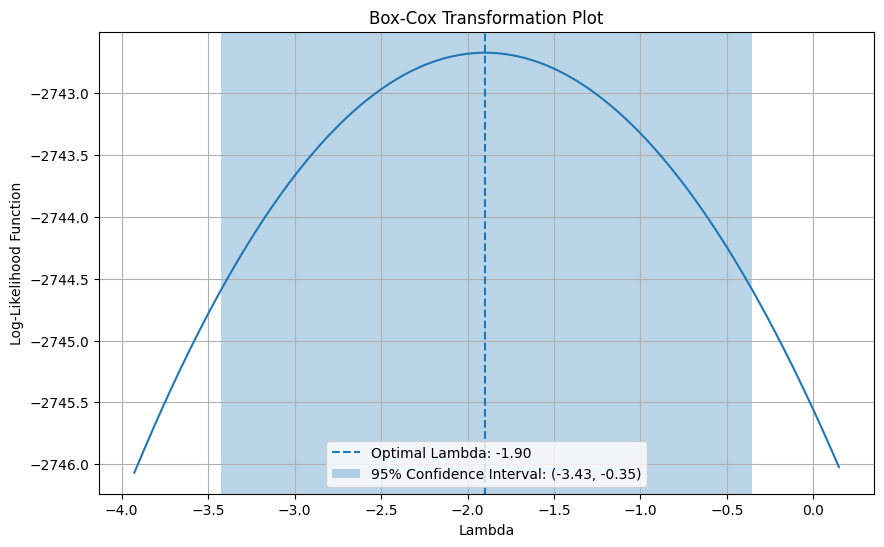

In [ ]:
# Plot Box-Cox likelihood
# Rentang lambda dibuat mencakup lambda optimal dan CI
lambdas = np.linspace(ci[0] - 0.5, ci[1] + 0.5, 300)

llf = [
    boxcox_llf(lmbda, telur['semarang'])
    for lmbda in lambdas
]

plt.figure(figsize=(10, 6))

plt.plot(lambdas, llf)

plt.axvline(
    lambda_fit,
    linestyle='--',
    label=f'Optimal Lambda: {lambda_fit:.2f}'
)

plt.axvspan(
    ci[0],
    ci[1],
    alpha=0.3,
    label=f'95% Confidence Interval: ({ci[0]:.2f}, {ci[1]:.2f})'
)

plt.xlabel('Lambda')
plt.ylabel('Log-Likelihood Function')
plt.title('Box-Cox Transformation Plot')
plt.legend()
plt.grid(True)

plt.show()

**Interpretasi:** Berdasarkan plot Box-Cox, kurva *log-likelihood* menunjukkan pola cekung dengan satu titik maksimum yang jelas. Titik maksimum tersebut berada pada $\lambda=-1{,}90$, yang merupakan estimasi parameter transformasi Box-Cox yang memaksimalkan nilai *log-likelihood*. Dengan demikian, transformasi Box-Cox dengan parameter $\lambda=-1{,}90$ dipilih untuk membantu menstabilkan ragam data harga telur di Semarang.

Area yang diarsir menunjukkan interval kepercayaan 95% untuk parameter $\lambda$, yaitu $(-3{,}43;-0{,}35)$. Interval tersebut tidak mencakup $\lambda=0$ maupun $\lambda=1$. Hal ini menunjukkan bahwa transformasi logaritmik ($\lambda=0$) maupun tanpa transformasi ($\lambda=1$) tidak didukung sebagai nilai parameter yang paling sesuai berdasarkan interval kepercayaan tersebut.

Nilai $\lambda$ optimal sebesar $-1{,}90$ menunjukkan bahwa transformasi yang sesuai memiliki pangkat negatif. Karena nilainya mendekati $-2$, bentuk transformasi yang digunakan secara matematis mendekati transformasi berpangkat negatif dua, meskipun transformasi yang diterapkan tetap menggunakan nilai estimasi $\lambda=-1{,}90$, bukan dibulatkan menjadi $-2$.

Selanjutnya, data hasil transformasi Box-Cox perlu diperiksa kembali kestasionerannya dalam nilai tengah. Apabila deret masih belum stasioner dalam nilai tengah, maka dilakukan *differencing* hingga diperoleh deret yang stasioner.

In [ ]:
# Simpan hasil transformasi Box-Cox
telur['boxcox'] = data_boxcox

**Interpretasi:** Setelah parameter optimal diperoleh sebesar $\lambda=-1{,}90$, hasil transformasi Box-Cox disimpan pada kolom baru bernama `boxcox`. Dengan demikian, setiap nilai harga telur pada kolom semarang memiliki nilai hasil transformasi yang bersesuaian pada kolom `boxcox`.

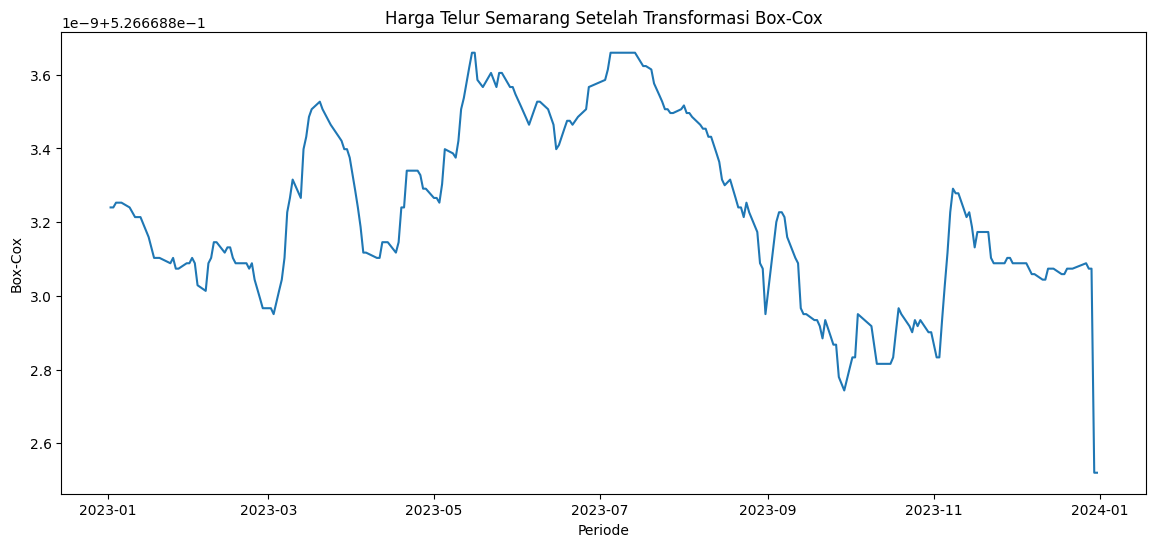

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(telur['periode'], telur['boxcox'])

plt.title('Harga Telur Semarang Setelah Transformasi Box-Cox')
plt.xlabel('Periode')
plt.ylabel('Box-Cox')

plt.show()

**Interpretasi:**

Berdasarkan grafik harga telur Semarang setelah transformasi Box-Cox dengan parameter $\lambda=-1{,}90$, deret waktu masih menunjukkan adanya perubahan level dari waktu ke waktu. Terlihat kenaikan pada sekitar Maret hingga Juli 2023, kemudian penurunan pada Agustus hingga Oktober 2023, dan kembali mengalami kenaikan pada November 2023.

Transformasi Box-Cox bertujuan untuk membantu menstabilkan ragam, sehingga transformasi ini tidak secara langsung menghilangkan tren atau ketidakstasioneran dalam nilai tengah. Berdasarkan grafik, fluktuasi deret setelah transformasi terlihat relatif lebih terkendali, tetapi masih terdapat perubahan pola dan level dari waktu ke waktu.

Oleh karena itu, berdasarkan grafik saja belum dapat disimpulkan bahwa deret telah stasioner dalam nilai tengah. Tahap selanjutnya adalah melakukan uji stasioneritas, seperti Augmented Dickey-Fuller (ADF). Apabila hasil pengujian menunjukkan bahwa deret belum stasioner dalam nilai tengah, maka dilakukan *differencing*.

# Differencing

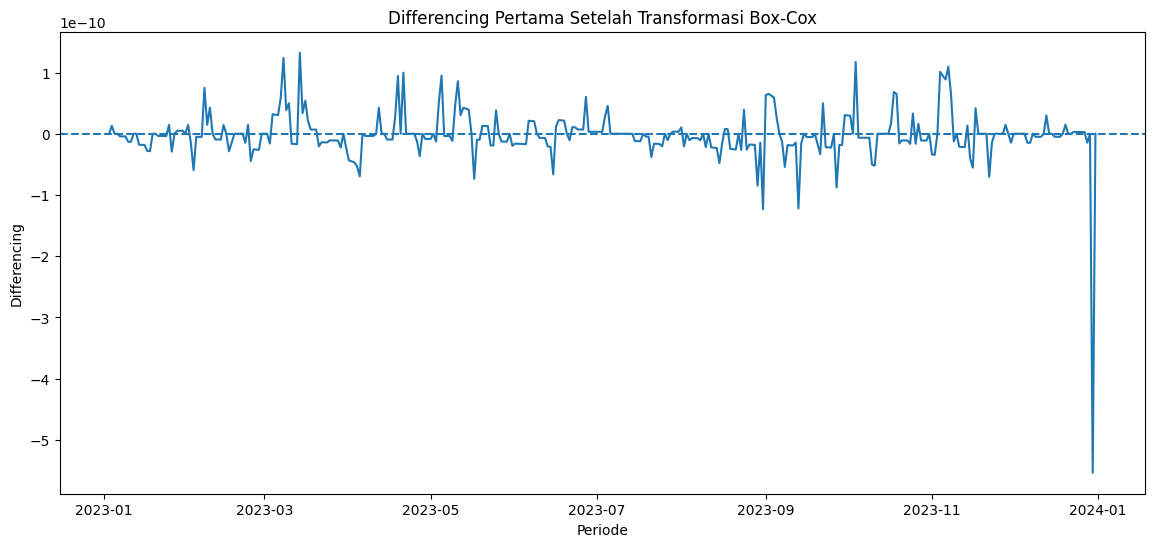

In [ ]:
telur['boxcox_diff1'] = telur['boxcox'].diff()

plt.figure(figsize=(14,6))

plt.plot(telur['periode'], telur['boxcox_diff1'])
plt.axhline(y=0, linestyle='--')

plt.title('Differencing Pertama Setelah Transformasi Box-Cox')
plt.xlabel('Periode')
plt.ylabel('Differencing')

plt.show()

**Interpretasi:**
Berdasarkan grafik, setelah dilakukan *differencing* pertama terhadap data yang telah ditransformasi Box-Cox, nilai hasil *differencing* berfluktuasi di sekitar garis nol. Tidak terlihat adanya pola tren yang konsisten, sehingga secara visual deret waktu lebih mendekati stasioner dalam nilai tengah.

Sebagian besar nilai *differencing* berada di sekitar nol dan bergerak secara bergantian di atas dan di bawah garis nol. Kondisi ini menunjukkan bahwa perubahan nilai antarperiode berfluktuasi di sekitar nilai rata-rata yang relatif konstan.

Namun, terdapat penurunan yang sangat tajam pada periode terakhir. Kondisi tersebut perlu diperiksa lebih lanjut untuk memastikan apakah disebabkan oleh perubahan harga yang besar antara dua periode terakhir atau terdapat permasalahan pada data. Selain itu, sumbu-$Y$ menggunakan skala $10^{-10}$, sehingga nilai hasil *differencing* secara numerik memang sangat kecil setelah transformasi Box-Cox.

Dengan demikian, secara visual *differencing* pertama telah membantu menghilangkan pola ketidakstasioneran dalam nilai tengah. Selanjutnya, kestasioneran deret perlu dikonfirmasi menggunakan uji Augmented Dickey-Fuller (ADF). Apabila hasil pengujian menunjukkan bahwa deret telah stasioner, maka tidak diperlukan *differencing* lanjutan.

In [ ]:
# Uji ADF setelah Differencing
hasil_adf = adfuller(telur['boxcox_diff1'].dropna())

print('ADF Statistic :', hasil_adf[0])
print('p-value       :', hasil_adf[1])

if hasil_adf[1] < 0.05:
    print('Kesimpulan: Data sudah stasioner.')
else:
    print('Kesimpulan: Data masih belum stasioner.')

ADF Statistic : -7.846246036136763
p-value       : 5.75893837067463e-12
Kesimpulan: Data sudah stasioner.


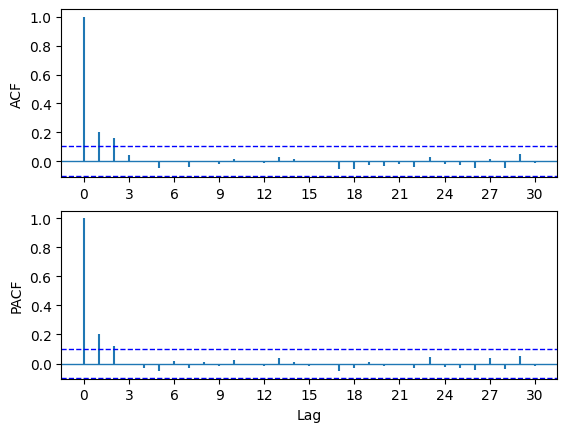

In [ ]:
acf_pacf_fig(
    telur['boxcox_diff1'].dropna(),
    both=True,
    lag=30
)

**Interpretasi:**

Berdasarkan plot ACF setelah dilakukan transformasi Box-Cox dan *differencing* pertama, terlihat bahwa autokorelasi pada lag 1 dan lag 2 masih berada di luar batas selang kepercayaan, sedangkan sebagian besar autokorelasi pada lag berikutnya berada di dalam batas tersebut. Pola ini menunjukkan bahwa ketergantungan antarperiode pada deret relatif kuat pada beberapa lag awal dan kemudian menurun dengan cepat. Pola *cut-off* pada ACF hingga sekitar lag 2 dapat menjadi indikasi awal adanya komponen **Moving Average (MA) orde 2**.

Pada plot PACF, nilai parsial pada lag 1 dan lag 2 terlihat signifikan, kemudian sebagian besar lag berikutnya berada dalam batas selang kepercayaan. Pola *cut-off* pada PACF hingga sekitar lag 2 dapat menjadi indikasi awal adanya komponen **Autoregressive (AR) orde 2**.

Tidak terlihat adanya pola yang berulang secara konsisten pada lag musiman, seperti lag 12, 24, dan seterusnya. Dengan demikian, berdasarkan pola ACF dan PACF, belum terdapat indikasi kuat adanya komponen musiman pada deret yang telah ditransformasi dan dilakukan *differencing*.

Pola ACF dan PACF tersebut memberikan indikasi awal bahwa model dengan komponen AR orde 2 dan MA orde 2 dapat dipertimbangkan. Oleh karena itu, salah satu model tentatif yang dapat digunakan adalah **ARIMA(2,1,2)**, dengan orde *differencing* $d=1$ yang telah ditetapkan berdasarkan hasil uji stasioneritas.

Namun, ACF dan PACF hanya digunakan sebagai dasar identifikasi awal sehingga **ARIMA(2,1,2) belum dapat langsung dinyatakan sebagai model terbaik**. Beberapa model kandidat di sekitar orde tersebut perlu diestimasi dan dibandingkan menggunakan kriteria seperti **AIC dan BIC**, kemudian dilakukan pemeriksaan diagnostik terhadap residual untuk memastikan bahwa residual telah memenuhi asumsi *white noise*.

<h2> Pertanyaan </h2>

Jika deret tidak stasioner dalam nilaitengah dan ragam, bagaimana urutan penanganan masalah ketidakstasioneran ini? Apakah differencing dahulu lalu transformasi Boxcox atau transformasi Boxcox dahulu lalu differencing?

Jawaban:

Untuk kasus data harga telur ini, alasan Box-Cox dilakukan terlebih dahulu baru differencing karena data menunjukkan dua masalah yang berbeda.

Pada data asli, hasil ADF memberikan $p=0{.}5696>0{.}05$, sehingga deret belum stasioner dalam nilai tengah. Di sisi lain, hasil Box-Cox memberikan $\lambda\approx-1{.}90$ dengan interval kepercayaan 95% sekitar $-3{.}43-0{.}35$. Karena $\lambda=1$ tidak termasuk dalam interval tersebut, ada indikasi bahwa skala/ragam data perlu distabilkan melalui transformasi.

Karena itu, urutannya adalah:

$$ \text{data asli} \rightarrow \text{Box-Cox} \rightarrow \text{differencing} $$

Box-Cox dikerjakan lebih dulu untuk menangani ketidakstasioneran ragam, kemudian differencing digunakan untuk menangani ketidakstasioneran nilai tengah.

Untuk data harga telur, urutan ini juga lebih masuk akal secara teknis karena seluruh harga masih positif, dengan nilai minimum sekitar $23.572$, sehingga syarat Box-Cox terpenuhi. Jika differencing dilakukan terlebih dahulu, hasilnya dapat menghasilkan nilai positif dan negatif, sehingga transformasi Box-Cox standar tidak dapat langsung diterapkan.